In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import shap

print("="*80)
print("Libraries Imported Successfully")
print("="*80)

Libraries Imported Successfully


In [3]:
import os

PROJECT_ROOT = r"C:\Users\User\OneDrive\Documents\IoT-Based-Intelligent-Building-DSS"

MODEL_DIR = os.path.join(PROJECT_ROOT, "models")

model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "final_xgboost_model.pkl"
    )
)



In [4]:
test_df = pd.read_csv(
    os.path.join(
        MODEL_DIR,
        "test_dataset.csv"
    )
)

print(test_df.shape)
X_test = test_df.drop(columns=["Total_Energy"])
y_test = test_df["Total_Energy"]
X_sample = X_test.sample(
    n=1000,
    random_state=42
)

print(X_sample.shape)


(40000, 12)
(1000, 11)


In [5]:
explainer = shap.TreeExplainer(model)

shap_values = explainer(X_sample)

print(shap_values.shape)

(1000, 11)


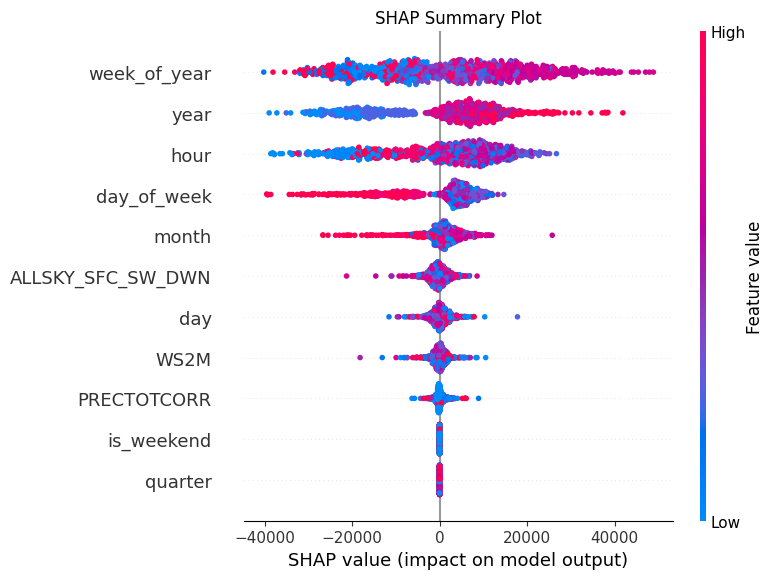

In [6]:
# ==========================================================
# SHAP Summary Plot
# ==========================================================

plt.figure(figsize=(10, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=11,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

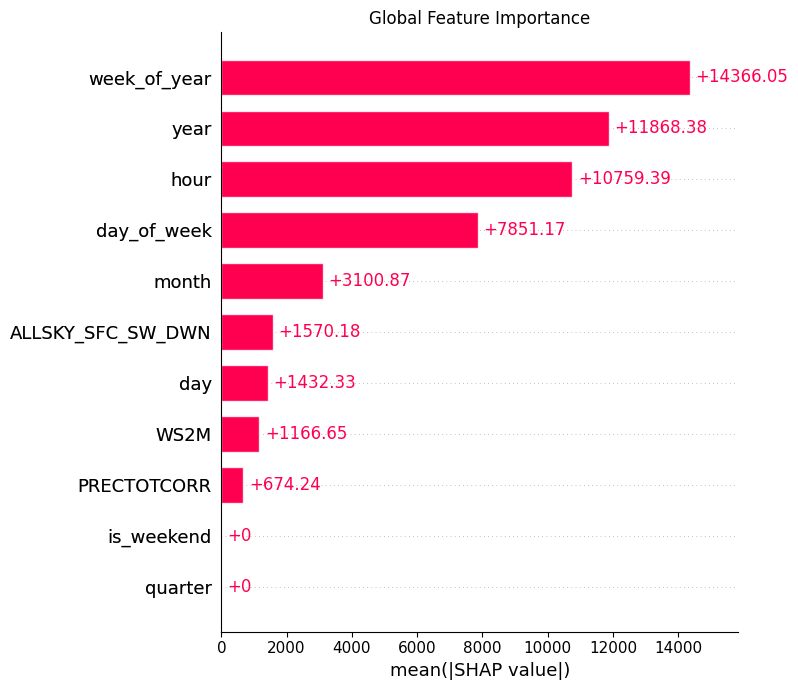

In [7]:
# ==========================================================
# SHAP Feature Importance
# ==========================================================

plt.figure(figsize=(10, 6))

shap.plots.bar(
    shap_values,
    max_display=11,
    show=False
)

plt.title("Global Feature Importance")
plt.tight_layout()
plt.show()

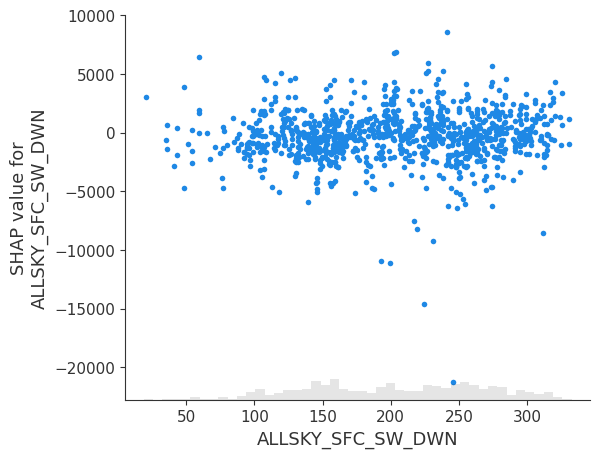

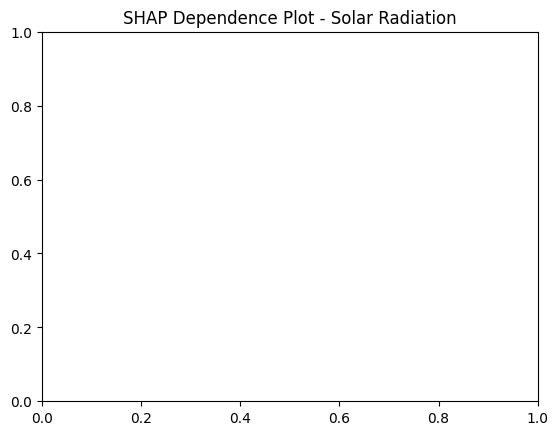

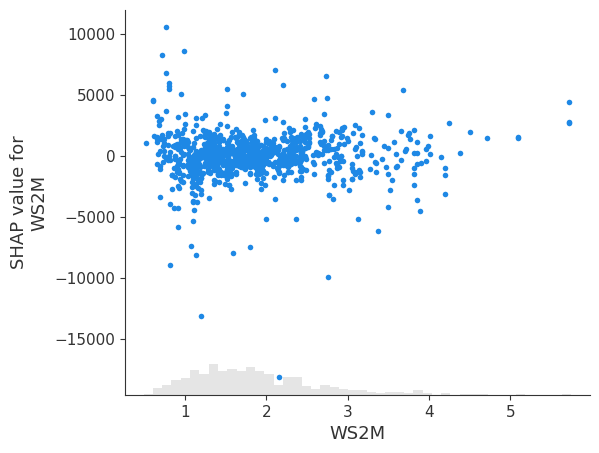

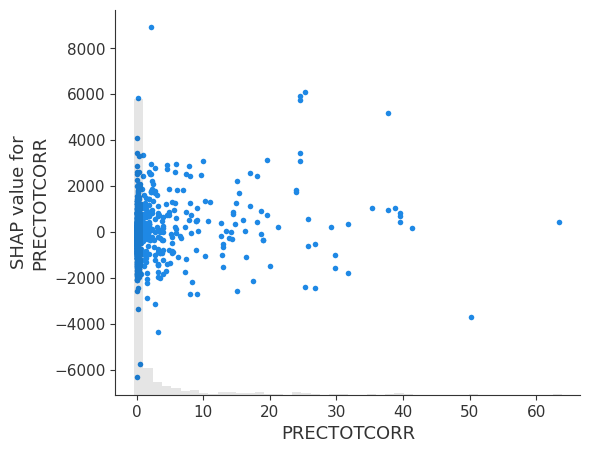

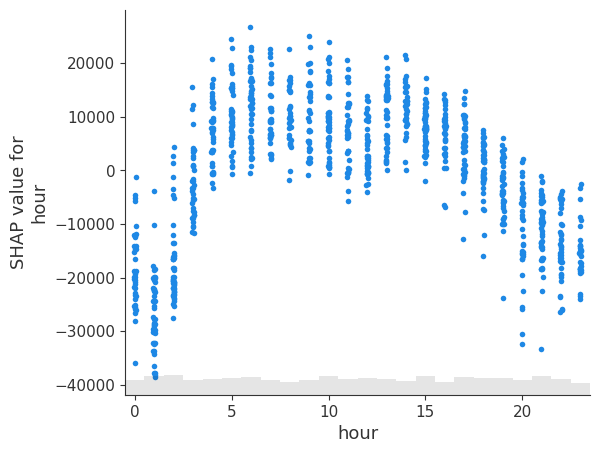

In [8]:
# ==========================================================
# SHAP Dependence Plot
# ==========================================================

shap.plots.scatter(

    shap_values[:, "ALLSKY_SFC_SW_DWN"]

)

plt.title("SHAP Dependence Plot - Solar Radiation")

plt.show()

shap.plots.scatter(
    shap_values[:, "WS2M"]
)

shap.plots.scatter(
    shap_values[:, "PRECTOTCORR"]
)

shap.plots.scatter(
    shap_values[:, "hour"]
)

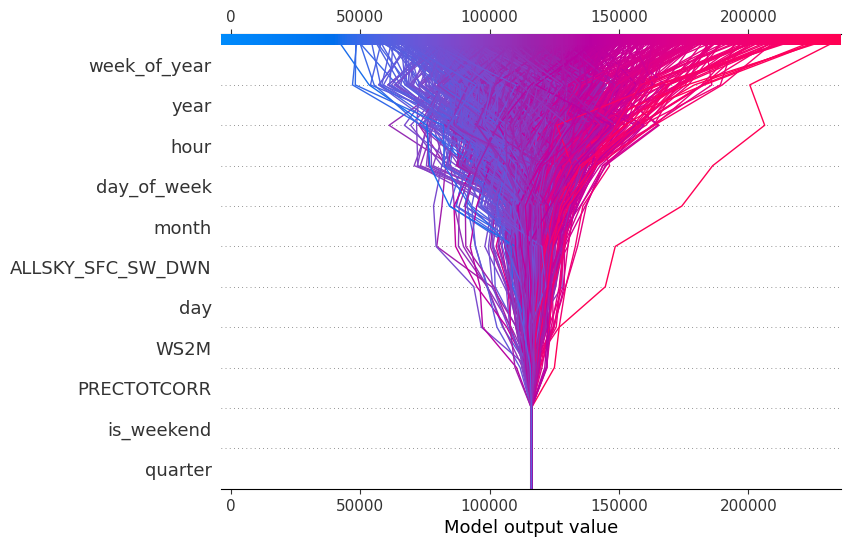

In [9]:
# ==========================================================
# SHAP Decision Plot
# ==========================================================

shap.decision_plot(

    explainer.expected_value,

    shap_values.values,

    X_sample

)

In [10]:
# ==========================================================
# Save SHAP Values
# ==========================================================

shap_df = pd.DataFrame(

    shap_values.values,

    columns=X_sample.columns

)

shap_df.to_csv(

    os.path.join(

        MODEL_DIR,

        "shap_values.csv"

    ),

    index=False

)

print("SHAP Values Saved Successfully")

SHAP Values Saved Successfully


In [11]:
# ==========================================================
# Mean Absolute SHAP Values
# ==========================================================

importance = pd.DataFrame({

    "Feature": X_sample.columns,

    "Mean_SHAP_Value": np.abs(
        shap_values.values
    ).mean(axis=0)

})

importance = importance.sort_values(

    by="Mean_SHAP_Value",

    ascending=False

)

display(importance)

importance.to_csv(

    os.path.join(

        MODEL_DIR,

        "shap_feature_importance.csv"

    ),

    index=False

)

,Feature,Mean_SHAP_Value
6,week_of_year,14366.049805
0,year,11868.383789
3,hour,10759.394531
4,day_of_week,7851.165527
1,month,3100.874268
8,ALLSKY_SFC_SW_DWN,1570.178955
2,day,1432.326416
9,WS2M,1166.651733
10,PRECTOTCORR,674.243774
5,is_weekend,0.000000
